<a href="https://colab.research.google.com/github/XaVIIIerg/deep-learning-nlp-coursework/blob/main/AdvNLP_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![MSE Logo](https://moodle.msengineering.ch/pluginfile.php/1/core_admin/logo/0x150/1643104191/logo-mse.png)

# AdvNLP Lab 1: Text Tokenization

## Introduction
The goal of this lab is to perform tokenization of texts using the [NLTK](http://www.nltk.org/) toolkit or using BPE from [SentencePiece](https://github.com/google/sentencepiece).  You will use the environment that you set up following the instructions of the introductory Jupyter notebook.  

You will use NLTK functions to get texts from the web and segment (split) them into sentences and words (also called *tokens*).  You will experiment with extracting statistics about the frequencies of tokens, and compare statistics for a novel and an undeciphered manuscript.

To submit your work, please execute all cells of this notebook, save it, and submit it as homework on Moodle.

## 2. Using NLTK to download and tokenize a text

Please install NLTK (the Natural Language Processing Toolkit) by following the installation instructions at the [NLTK website](http://www.nltk.org/install.html).  To use NLTK, first `import nltk`.  NLTK has a download manager (try `nltk.download()` in command line) which can import several resources, including corpora.

To get started, look at [Chapter 1](http://www.nltk.org/book/ch01.html) of the [online NLTK book (NLP with Python)](http://www.nltk.org/book/) and use the commands there as a model.  <span style="color:gray">Note: the online book was updated for Python 3, but the [printed book](http://shop.oreilly.com/product/9780596516499.do) is only for Python 2.</span>

In [ ]:
import nltk
nltk.download('punkt') # execute only once after installing NLTK, then comment it out

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

**1a.** Using inspiration from [Chapter 3 (3.1. Processing Raw Text) of the NLTK book](http://www.nltk.org/book/ch03.html), download a book from the Gutenberg Project in text format. What is its size? Are these bytes or characters? <span style="color:gray">Note: to learn more about special characters, you can refer to Python's documentation of [Unicode support](https://docs.python.org/3/howto/unicode.html).</span>

In [ ]:
from urllib import request # you may need to run first:  !pip install urllib

In [ ]:
url = "http://www.gutenberg.org/files/2554/2554-0.txt"
response = request.urlopen(url)
raw_text = response.read().decode('utf8')

In [ ]:
len(raw_text) # The downloaded book has a size of 1135213 characters.

1135213

In [ ]:
type(raw_text) # The characters are string.

str

**1b.** We want to keep only the original text of the book, without the header, preface, or license.  Please determine (e.g. by locating the position of initial and final strings) how much your should trim from the beginning and from the end in order to keep only the original text of the book (including titles). Please remove unnecessary paragraph marks (e.g. if the text is segmented into fixed-length lines). Save the result as a new string and display its length.

In [ ]:
import re
print("position of initial string : ")
deb = raw_text[85:].find("CRIME AND PUNISHMENT")+ 85
# Add and remove 85 because we want to catch the second "CRIME AND PUNISHMENT", not the one before the preface
print(deb)

print("position of final string : ")
end = raw_text.find("*** END OF THE PROJECT GUTENBERG EBOOK 2554 ***")
print(end)

only_text = raw_text[deb:end]
text = only_text.replace("\n", " ")

# Improvement : removing of the "CHAPTER", "PART", "", _ and big spaces (length > 2)
regex1 = re.compile(r'PART [A-Z]')
regex2 = re.compile(r'CHAPTER [A-Z]')

text = re.sub(regex1, "", text)
text = re.sub(regex2, "", text)
text = text.replace("”", "")
text = text.replace("“", "")
text = text.replace("_", "")

for x in range(1,10):
  text = text.replace(" "*x," ")

print("size of the cleared text : ")
len(text)

position of initial string : 
4613
position of final string : 
1135165
size of the cleared text : 


1117606

**1c.** NLTK defines a function to segment a text into sentences (`nltk.sent_tokenize(...)` (documented [here](https://www.nltk.org/api/nltk.tokenize.html#nltk.tokenize.word_tokenize))) and another one to tokenize a text into words (`nltk.word_tokenize(...)` (documented [here](https://www.nltk.org/api/nltk.tokenize.html#nltk.tokenize.sent_tokenize))). <span style="color:gray">Note: NLTK calls the first one "sentence tokenization", which is unusual.</span>

Please segment the text above into sentences with NLTK, display the number of sentences, and display five sentences of your choice.  Please assess briefly the quality of the segmentation.  If you think that some special characters degrade the results, please go back and remove or replace them in the full text.

In [ ]:
nltk.download('punkt_tab')
tokenizer = nltk.sent_tokenize(text)
print("number of sentences : ", len(tokenizer))
tokenizer[:5]

# To improve the quality, we have remove some special characters that seems to distrub the tokenization: ”, “, _ but it's possible that other characters are still remaining in the text.
# However, the tokenization seems proper.

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


number of sentences :  14571


['CRIME AND PUNISHMENT  On an exceptionally hot evening early in July a young man came out of the garret in which he lodged in S. Place and walked slowly, as though in hesitation, towards K. bridge.',
 'He had successfully avoided meeting his landlady on the staircase.',
 'His garret was under the roof of a high, five-storied house and was more like a cupboard than a room.',
 'The landlady who provided him with garret, dinners, and attendance, lived on the floor below, and every time he went out he was obliged to pass her kitchen, the door of which invariably stood open.',
 'And each time he passed, the young man had a sick, frightened feeling, which made him scowl and feel ashamed.']

**1d.** Please save the resulting text into a file, one sentence per line.

In [ ]:
file = open("text.txt", "w")
for sentence in tokenizer:
    file.write(sentence + "\n")
file.close()

**1e.** Please segment each sentence into tokens,  store the result in a new variable (a list of lists), and display the same five sentences as above.  Please comment briefly on the quality of the tokenization.

In [ ]:
sentences = []
for sentence in tokenizer:
    sentences.append(nltk.word_tokenize(sentence))
sentences[:5]
# The tokenization in word is correct, we can see that the words and the sentences are well divided.

[['CRIME',
  'AND',
  'PUNISHMENT',
  'On',
  'an',
  'exceptionally',
  'hot',
  'evening',
  'early',
  'in',
  'July',
  'a',
  'young',
  'man',
  'came',
  'out',
  'of',
  'the',
  'garret',
  'in',
  'which',
  'he',
  'lodged',
  'in',
  'S.',
  'Place',
  'and',
  'walked',
  'slowly',
  ',',
  'as',
  'though',
  'in',
  'hesitation',
  ',',
  'towards',
  'K.',
  'bridge',
  '.'],
 ['He',
  'had',
  'successfully',
  'avoided',
  'meeting',
  'his',
  'landlady',
  'on',
  'the',
  'staircase',
  '.'],
 ['His',
  'garret',
  'was',
  'under',
  'the',
  'roof',
  'of',
  'a',
  'high',
  ',',
  'five-storied',
  'house',
  'and',
  'was',
  'more',
  'like',
  'a',
  'cupboard',
  'than',
  'a',
  'room',
  '.'],
 ['The',
  'landlady',
  'who',
  'provided',
  'him',
  'with',
  'garret',
  ',',
  'dinners',
  ',',
  'and',
  'attendance',
  ',',
  'lived',
  'on',
  'the',
  'floor',
  'below',
  ',',
  'and',
  'every',
  'time',
  'he',
  'went',
  'out',
  'he',
  'was',

**1f.** Please display the total number of tokens found in the text by this method (sentence segmentation followed by sentence-level tokenization).

In [ ]:
number_of_tokens = 0
for sentence in sentences:
  number_of_tokens += len(sentence)
print("number of tokens in the text : ")
print(number_of_tokens)

number of tokens in the text : 
245660


**1g.** Please tokenize now directly the initial full text, without segmenting it into sentences.  Please display the total number of tokens found, and compare this number with the one obtained above.

In [ ]:
full_tokens = nltk.word_tokenize(text)
print("number of token in the full clean text : ")
print(len(full_tokens))
# The numbers of tokens are equals. There is no need to, firstly, tokenize with the sentence before using the tokenization of the words. We can directly tokenize with the words.

number of token in the full clean text : 
245660


## 2. Computing lexical statistics

**2a.** Please determine the size of the vocabulary of your text (the number of unique *types*) by converting the list of tokens to a Python `set`.  Note that these *types* include punctuations and other symbols found through tokenization, and that uppercase/lowercase letters are different.

In [ ]:
vocabulary = set(full_tokens)
print("size of the vocabulary (= number of tokens) : ")
print(len(vocabulary))

size of the vocabulary (= number of tokens) : 
10395


**2b.** What is the type-to-token ratio (TTR) of your text?

In [ ]:
# TTR = nb of types / nb of tokens
TTR = len(vocabulary) / number_of_tokens
TTR
# There is only 4.2% of types in the entire vocabulary. A small number of types can represents the all text. Tokens are highly repeated.
# The text is predictive.

0.04231458112838883

**2c.** Please create a `nltk.Text` object from the tokenized version of your text, without the sentence segmentation.  Such an object will enable you to compute statistics using NLTK functions.  [Chapter 1 of the NLTK book](http://www.nltk.org/book/ch01.html) provides examples of use.

<span style="color:gray">Note: `nltk.word_tokenize()` and `nltk.sent_tokenize()` apply to strings but not directly to `ntlk.Text` objects.  A `nltk.Text` object can store either a string, or a list of words, or a list of sentences (list of lists of strings).</span>

In [ ]:
obj = nltk.Text(full_tokens) # the tokenized text on the full cleaned text
obj

<Text: CRIME AND PUNISHMENT On an exceptionally hot evening...>

**2d.** Please construct the frequency distribution of your text, which is an object of the `nltk.FreqDist`class, instantiated directly from the `nltk.Text` object containing the list of all words. See [Sec. 3.1 of Ch. 1 of the NLTK book](http://www.nltk.org/book/ch01.html#frequency-distributions).  Using the `most_common` method on the `FreqDist` object, find the 50 most frequent words in your text, and display among them the words that have at least 4 characters.  Please comment briefly on the results.

In [ ]:
freq = nltk.FreqDist(obj)
freq.most_common(50)
for word in freq.most_common(50):
  if len(word[0]) >= 4:
    print(word)
# The words that appears the most, among those who have at least a size of 4, are words that are very used in english like "that" or "have",
# or the name of the main charactere of the story (Raskolnikov)

('that', 3064)
('with', 1672)
('have', 1103)
('Raskolnikov', 784)
('what', 753)
('were', 701)
('from', 697)
('....', 683)


## 3. Testing Zipf's law on a book

[Zipf's law](https://en.wikipedia.org/wiki/Zipf%27s_law) formalizes the following empirical observation for large texts or collections: when ranking word types by decreasing frequencies, the ranks *x* (i.e. 1, 2, 3, ...) and the numbers of occurrences *y* (e.g. 948, 321, 146, ...) of each word are related approximately by the formula *y = a / x^b*.  The parameters *a* and *b* depend on the text.  If plotted in log-log coordinates, this relation results in a linear plot (because log(*y*) = *a* - *b* log(*x*)).

**3a.** Using the `FreqDist` object, please collect the frequencies of the 1000 most frequent words, rank them by decreasing values, and plot the (*rank*, *frequency*) curve on a log-log scale by setting the `.xscale("log")` and `.yscale("log")` parameters of the plot.

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
ranks = list(range(1, 1000 + 1)) # we create a list : [1, 2, ..., 999, 1000]

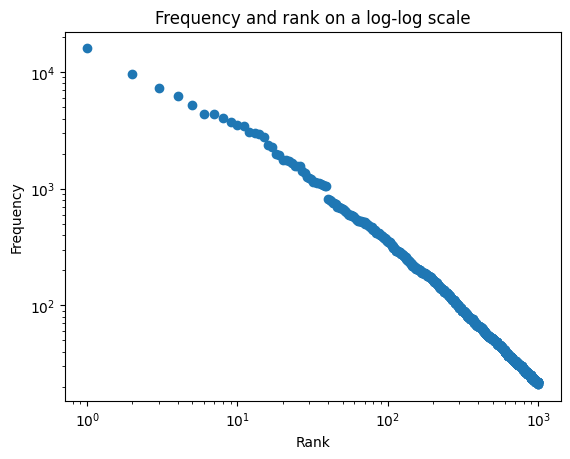

In [ ]:
freq_1000 = freq.most_common(1000)
sorted_freq_1000 = [item[1] for item in freq_1000] # we keep only the number (not the charactere/token/word...)

plt.scatter(ranks, sorted_freq_1000)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Frequency and rank on a log-log scale")
plt.xscale("log")
plt.yscale("log")
plt.show()
# We can retrieve the shape of the decreasing line of the Zipf's law.

**3b.** Please find the values of *a* and *b* which lead to the closest matching between the observation curve (*rank*, *frequency*) and Zipf's curve (*x*, *y = a / x^b*).  You can use `scipy.optimize.curve_fit()` or even a trial-and-error approach.  Please display both curves on the same graph with a log-log scale to visualize how close they are.  Please also display the optimal values of *a* and *b*.

In [ ]:
import numpy as np
import scipy

Optimal parameters: a = 16993.63603932513, b = 0.79289083806836


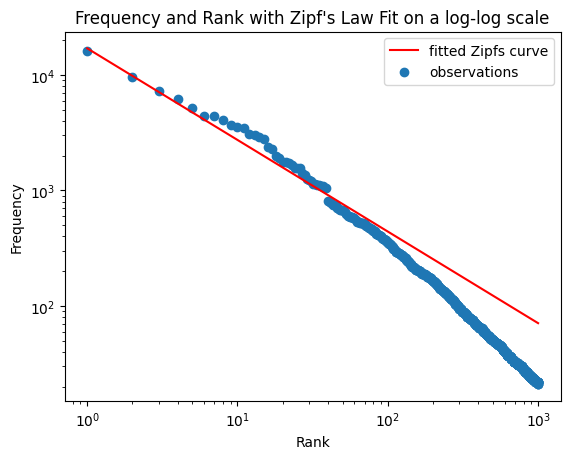

In [ ]:
freq_array = np.array(sorted_freq_1000, dtype=float) # converting the list of the 1000 frequencies into an array

def zipf(x, a, b):
    # equation of a line (= zipf law)
    return a / np.power(x, b) # y = a / x^b

# scipy.optimize.curve_fit : Use non-linear least squares to fit a function, f, to data.
# return :
#   popt (array) : Optimal values for the parameters so that the sum of the squared residuals of f(xdata, *popt) - ydata is minimized.
#   pcov (2-D array) : The estimated approximate covariance of popt.
popt, pcov = scipy.optimize.curve_fit(zipf, ranks, freq_array)
a_opt = popt[0]
b_opt = popt[1]

print(f"Optimal parameters: a = {a_opt}, b = {b_opt}")

fitted = zipf(ranks, a_opt, b_opt)

plt.plot(ranks, fitted, 'red', label = 'fitted Zipfs curve')
plt.scatter(ranks, sorted_freq_1000, label = 'observations')
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.title("Frequency and Rank with Zipf's Law Fit on a log-log scale")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()

**3c.** Based on the graph, can you conclude that the frequencies of tokens in the text you select corroborate Zipf's law, or rather contradict it?

In [ ]:
# The two curves are similars : they are close at the beginning and then matches the declining tendency similarly.
# We have shown that Zipf's law is accurate on this book.

## 4.  Does an undeciphered manuscript obey Zipf's law?

The [Voynich manuscript](https://en.wikipedia.org/wiki/Voynich_manuscript) is an undeciphered manuscript from the 15th century.   Its script and language are still unknown, and it may even be a hoax.  You can read more about it at [Voynich.nu](http://www.voynich.nu/), which provides pictures and transcriptions.  A version of it converted to ASCII characters (corresponding to symbols from the manuscript) and tokenized with one word per line is made available for this lab as `voynich.txt`.

**4a.** Please compute the number of tokens, the number of types, and the type-to-token ration (TTR) for this document.  How does it compare with your previous text?

In [ ]:
VOYNICH = open("voynich.txt", "r")
voynich = VOYNICH.read()

voynich_tokens = nltk.word_tokenize(voynich)
print("number of token in voynich : ", len(voynich_tokens))

voynich_vocabulary = set(voynich_tokens)
voynich_ttr = len(voynich_vocabulary) / len(voynich_tokens)
print("TTR : ", voynich_ttr)
# With a TTR equal to 25%, this book has a lot of tokens that are, on average, used 4 times. The words are more used than in the last text.

number of token in voynich :  21731
TTR :  0.2534167778749252


**4b.** Considering the 1000 most frequent tokens of the Voynich manuscript, do they follow Zipf's law?  Please also display the optimal values of *a* and *b* and the mean absolute percentage error.

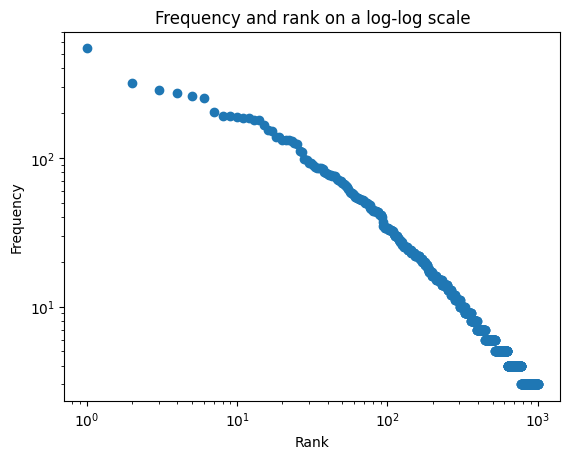

/tmp/ipython-input-98380372.py:5: RuntimeWarning: overflow encountered in divide
  return a / np.power(x, b) # y = a / x^b


Optimal parameters: a = 623.9868055334128, b = 0.6301796382170898


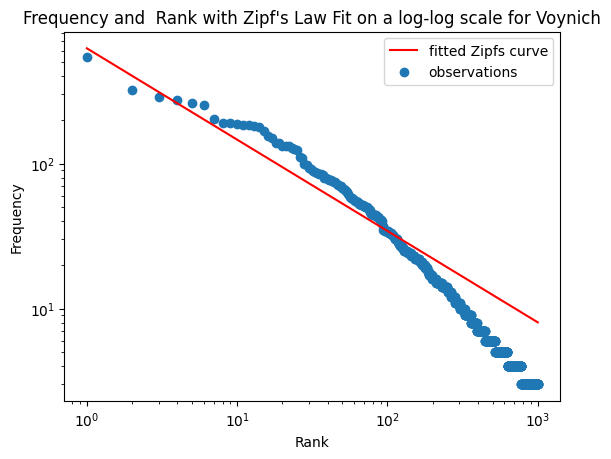

Mean aboslute percentage error 7.2120983996076555


In [ ]:
voynich_freq_1000 = nltk.FreqDist(nltk.Text(voynich_tokens)).most_common(1000)
voynich_sorted_freq_1000 = [item[1] for item in voynich_freq_1000]

# Zipf's law
plt.scatter(ranks, voynich_sorted_freq_1000)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Frequency and rank on a log-log scale")
plt.xscale("log")
plt.yscale("log")
plt.show()

# optimal values of a and b
voynich_freq_array = np.array(voynich_sorted_freq_1000, dtype=float)
voynich_popt, voynich_pcov = scipy.optimize.curve_fit(zipf, ranks, voynich_freq_array)
voynich_a_opt = voynich_popt[0]
voynich_b_opt = voynich_popt[1]

print(f"Optimal parameters: a = {voynich_a_opt}, b = {voynich_b_opt}")

voynich_fitted = zipf(ranks, voynich_a_opt, voynich_b_opt)

plt.plot(ranks, voynich_fitted, 'red', label = 'fitted Zipfs curve')
plt.scatter(ranks, voynich_sorted_freq_1000, label = 'observations')
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.title("Frequency and  Rank with Zipf's Law Fit on a log-log scale for Voynich")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()

# Mean aboslute percentage error (MAPE)
MAPE = 0
for i in range(1, 1001):
  MAPE += abs(zipf(i, voynich_a_opt, voynich_b_opt) - voynich_sorted_freq_1000[i-1])
MAPE = MAPE / 1000
print("Mean aboslute percentage error", MAPE)

**4c.** What are your conclusions regarding Voynich's manuscript?  Is it likely to be similar to a real text in an unknown language?  In your answer, consider the values of TTR, the two parameters *a* and *b*, and the fitting of the *y = a / x^b* curve.

In [ ]:
# The voynich text matchs to the Zipf's law. We can see that the red and blue lines follows the same trend. The mean absolute percentage error is very law. Zipf's law is confirmed.
# The TTR is very different from the last between because voynich is a very small text,
# so it naturally has less reutilized words than the previous text.
# The values of a and b are very different but the Zipf's law is still verified.

## 5. Testing Zipf's law with BPE tokenization of the book and the manuscript

**5a.** Please install the SentencePiece tokenizer from https://github.com/google/sentencepiece (with `!pip install sentencepiece`).  Please read the "Usage instructions” from the repo, or the ones for the [Python module](https://github.com/google/sentencepiece/blob/master/python/README.md).  Please construct a BPE subword vocabulary (i.e. "train" the model) on your text, of size 1100.  Use here the file you saved in (1d).

In [ ]:
import sentencepiece as spm

In [ ]:
spm.SentencePieceTrainer.train(
    input='text.txt',
    model_prefix='bpe_model',
    vocab_size=1100
)

sp = spm.SentencePieceProcessor()
sp.load('bpe_model.model')

True

**5b.** Please tokenize your text with this model, and display the number of tokens (i.e. size of vocabulary), the number of types, and the type-to-token ratio (TTR).

In [ ]:
bpe_tokens = []
with open('text.txt', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            t = sp.encode(line, out_type=str)
            bpe_tokens.extend(t)

bpe_TTR = len(set(bpe_tokens)) / len(bpe_tokens)
print("TTR : ", bpe_TTR)

TTR :  0.0031729886275340823


**5c.** Please fit a Zipf's curve to the book, as tokenized with BPE, and display the two curves on a log-log scale.

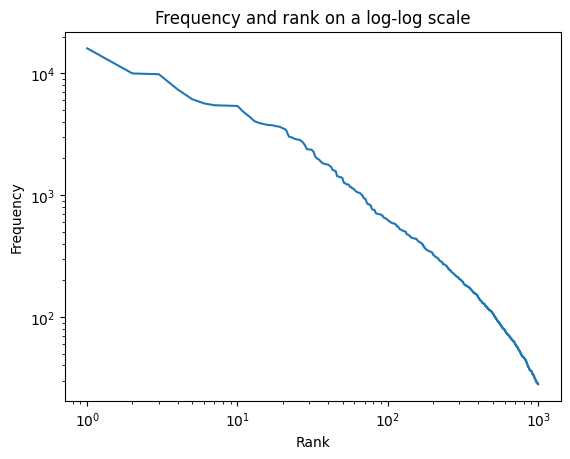

Optimal parameters: a = 18190.98954343542, b = 0.6893743685331069


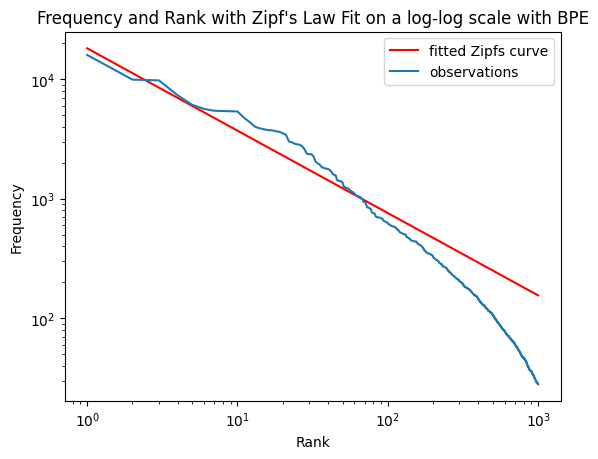

In [ ]:
bpe_freq_1000 = nltk.FreqDist(bpe_tokens).most_common(1000)
bpe_sorted_freq_1000 = [item[1] for item in bpe_freq_1000]

# Zipf's law
plt.loglog(ranks, bpe_sorted_freq_1000)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Frequency and rank on a log-log scale")
plt.show()

# optimal values of a and b
bpe_freq_array = np.array(bpe_sorted_freq_1000, dtype=float)
bpe_popt, bpe_pcov = scipy.optimize.curve_fit(zipf, ranks, bpe_freq_array)
bpe_a_opt = bpe_popt[0]
bpe_b_opt = bpe_popt[1]

print(f"Optimal parameters: a = {bpe_a_opt}, b = {bpe_b_opt}")

bpe_fitted = zipf(ranks, bpe_a_opt, bpe_b_opt)

plt.loglog(ranks, bpe_fitted, 'red', label = 'fitted Zipfs curve')
plt.loglog(ranks, bpe_sorted_freq_1000, label = 'observations')

plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.title("Frequency and Rank with Zipf's Law Fit on a log-log scale with BPE")
plt.legend()
plt.show()

**5d.** Please perform the same operations on the Voynich manuscript with a BPE tokenizer build from this text.  Please display the number of tokens, types, TTR, and the fitted Zipf's curve.

In [ ]:
spm.SentencePieceTrainer.train(
    input='voynich.txt',
    model_prefix='bpe_model',
    vocab_size=1100
)

sp2 = spm.SentencePieceProcessor()
sp2.load('bpe_model.model')

voynich_bpe_tokens = []
with open('voynich.txt', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            t = sp.encode(line, out_type=str)
            voynich_bpe_tokens.extend(t)

voynich_bpe_TTR = len(set(voynich_bpe_tokens)) / len(voynich_bpe_tokens)
print("TTR : ", voynich_bpe_TTR)

TTR :  0.0019626696271918954


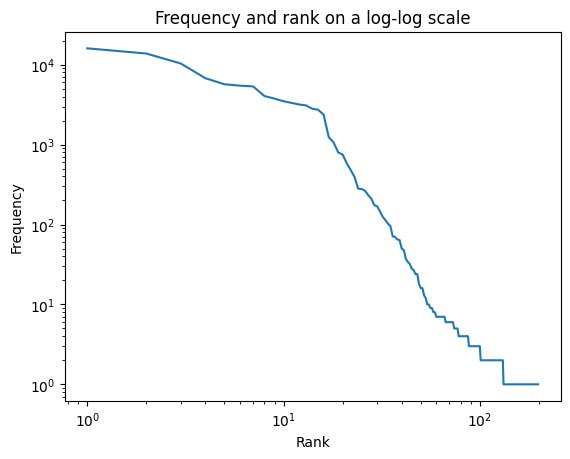

Optimal parameters: a = 19419.34317780338, b = 0.8913088791578755


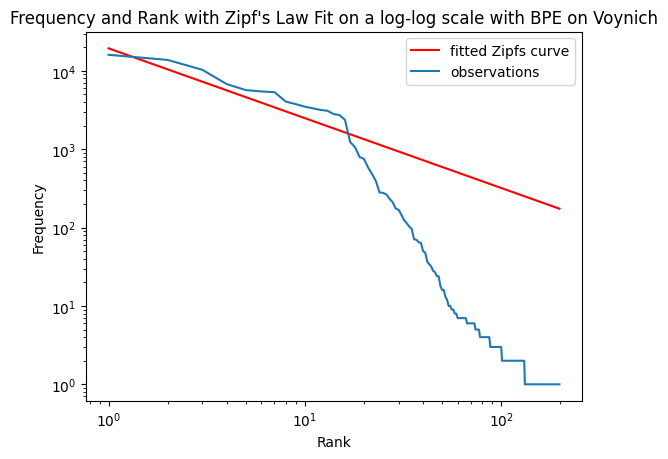

In [ ]:
voynich_bpe_freq_1000 = nltk.FreqDist(voynich_bpe_tokens).most_common(1000)
voynich_bpe_sorted_freq_1000 = [item[1] for item in voynich_bpe_freq_1000]
voynich_bpe_ranks = list(range(1, len(voynich_bpe_sorted_freq_1000) + 1))

# Zipf's law
plt.loglog(voynich_bpe_ranks, voynich_bpe_sorted_freq_1000)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Frequency and rank on a log-log scale")
plt.show()

# optimal values of a and b
voynich_bpe_popt, voynich_bpe_pcov = scipy.optimize.curve_fit(zipf, voynich_bpe_ranks, voynich_bpe_sorted_freq_1000)
voynich_bpe_a_opt = voynich_bpe_popt[0]
voynich_bpe_b_opt = voynich_bpe_popt[1]

print(f"Optimal parameters: a = {voynich_bpe_a_opt}, b = {voynich_bpe_b_opt}")

voynich_bpe_fitted = zipf(voynich_bpe_ranks, voynich_bpe_a_opt, voynich_bpe_b_opt)

plt.loglog(voynich_bpe_ranks, voynich_bpe_fitted, 'red', label = 'fitted Zipfs curve')
plt.loglog(voynich_bpe_ranks, voynich_bpe_sorted_freq_1000, label = 'observations')

plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.title("Frequency and Rank with Zipf's Law Fit on a log-log scale with BPE on Voynich")
plt.legend()
plt.show()

**5e.** Please conclude: when using BPE, does the Voynich manuscript exhibit similar properties of token frequency as a real text?  Are the differences larger or smaller when using BPE then when using word-based tokenization ?

In [ ]:
# BPE merge the tokens to create new ones with meaning, from the text itself. However, in voynich.txt, there is no apparent meaning.
# Due to that property of BPE, there are large differences between the Zipf's law and the observations.
# The real text conserves its fitting to the Zipf's law with BPE because we keep a tokenization based on small subwords to bigger one, by applying somes rules of merging.

## End of AdvNLP Lab 1
Please clean and save the completed notebook, and upload it to Moodle.